CNN model initialized with 145 input features.
Model features include: ['Carbon', 'Nitrogen', 'Phosphorus', 'Hydrogen', 'Titanium', 'Gold', 'Lithium', 'Nickel', 'Cobalt', 'Manganese', 'Oxygen', 'Cadmium', 'Selenium', 'Sulfur', 'Silicon']...


Epoch 50/200, Loss: 0.118419


Epoch 100/200, Loss: 0.080152


Epoch 150/200, Loss: 0.070845


Epoch 200/200, Loss: 0.062532
CNN weights saved to cnn_model_weights.pth


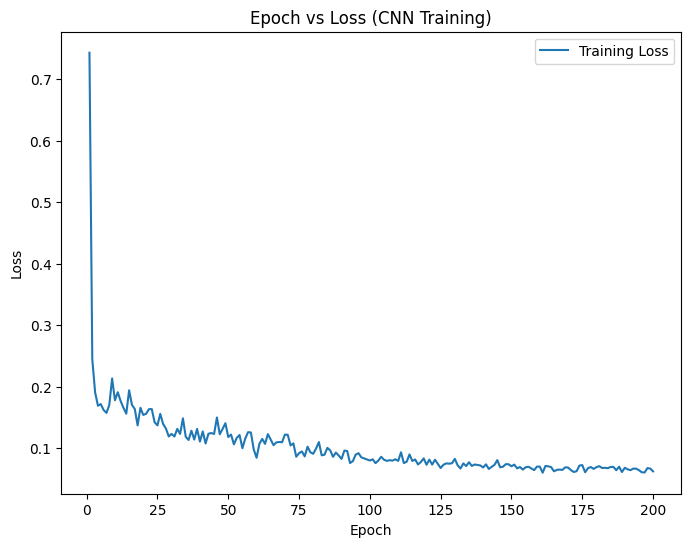

Extracting features from CNN...
Feature extraction complete.
Tuning XGBoost hyperparameters...
Best XGB parameters found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Training final Bagging+XGBoost model...
Bagging + XGB model saved to Bagging_XGB_CNN_features.pkl
Bagging + XGBoost performance on validation set: MAE = 0.1853
Bagging + XGBoost performance on test set: MAE = 0.2163
Starting SHAP analysis on the *full* pipeline...
Calculating SHAP values... (this may take a moment)


PermutationExplainer explainer: 66it [02:15,  2.26s/it]                        


SHAP analysis complete.
Plotting SHAP beeswarm plot...
SHAP plot saved to shap_beeswarm.pdf


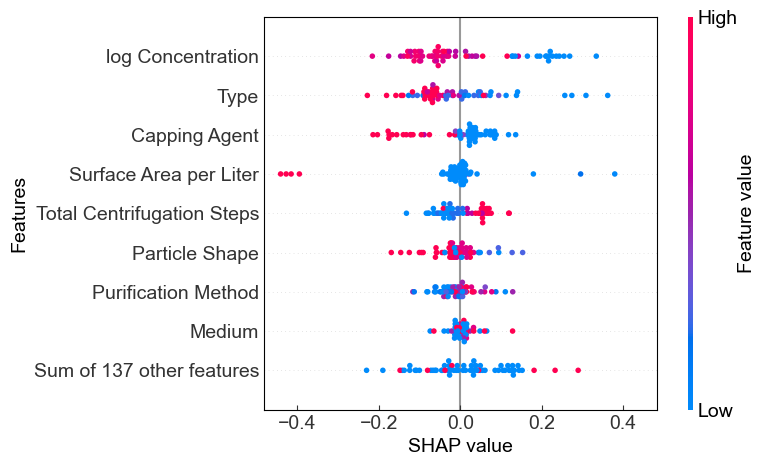

Saved predictions and actual values to MCCX_plot.csv (rows=117)


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import BaggingRegressor
import random
import matplotlib.pyplot as plt
import joblib
import shap  # Import SHAP for explainability

# ------------------------------
# 0. Set Random Seed
# ------------------------------
# Set seed for reproducibility across all libraries
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# 1. Data Preparation
# ------------------------------

# --- 1a. Load and Clean ---
def load_CSN_data():
    # Using the original CSV name from the first script for compatibility.
    # Please change this path if 'Master_List_LCPLCP.csv' is correct.
    csv_path = '../CSN_Viability_Database_2025.csv'
    return pd.read_csv(csv_path)

CSN = load_CSN_data()

# Drop metadata columns
CSN = CSN.drop(['Example ID', 'Source', 'Figure ID', 'Data Provider', 'PI',
                'Date Received', 'Data Measurment Published', 'Prior Exposure', 'Comments', 'Error'], axis=1)

# --- 1b. Initial Feature Engineering & One-Hot Encoding ---

# One-hot encode all categorical variables
CSN_prepared = pd.get_dummies(CSN, dtype=int)

# Engineer 'Surface Area per Liter'
CSN_prepared['Surface Area per Liter'] = CSN_prepared['Surface Area (NMC) (m2/g)'] * CSN_prepared['Concentration (mg/L)']
CSN_prepared = CSN_prepared.drop(['Surface Area (NMC) (m2/g)'], axis=1)

# Engineer 'log Concentration'
CSN_prepared['log Concentration'] = np.log10(CSN_prepared['Concentration (mg/L)'] + 1e-9)
CSN_prepared = CSN_prepared.drop(['Concentration (mg/L)'], axis=1)

# Standardize target column name (remove potential trailing space)
if 'Viability Fraction ' in CSN_prepared.columns:
    CSN_prepared = CSN_prepared.rename(columns={'Viability Fraction ': 'Viability_Fraction'})

# --- 1c. Feature Grouping (as requested) ---
# We now apply the grouping logic to the one-hot encoded DataFrame.
# NOTE: This grouping is for features that were *already* one-hot encoded
# (e.g., a 'Type' column with values 'A', 'B' becoming 'Type_A', 'Type_B').
# Based on the user's image, columns like 'Gold' are LIKELY already separate
# columns and will NOT be grouped here.

# ----- Group 1: Particle Diameter -----
diameter_cols = ['Particle Diameter Dimension 1 (nm)', 
                 'Particle Diameter Dimension 2 (nm)', 
                 'Particle Diameter Dimension 3 (nm)']
# Ensure columns exist before processing
if all(col in CSN_prepared.columns for col in diameter_cols):
    CSN_prepared['Particle Diameter (nm)'] = CSN_prepared[diameter_cols].mean(axis=1)
    CSN_prepared = CSN_prepared.drop(columns=diameter_cols)

# ----- Group 2: Type -----
type_cols = [col for col in CSN_prepared.columns if col.startswith('Type_')]
if type_cols:
    def get_type(row):
        active = row[type_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Type_', '')
    CSN_prepared['Type'] = CSN_prepared.apply(get_type, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=type_cols)

# ----- Group 3: Capping Agent -----
cap_cols = [col for col in CSN_prepared.columns if col.startswith('Capping Agent_')]
if cap_cols:
    def get_capping_agent(row):
        active = row[cap_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Capping Agent_', '')
    CSN_prepared['Capping Agent'] = CSN_prepared.apply(get_capping_agent, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=cap_cols)

# ----- Group 4: Particle Shape -----
shape_cols = [col for col in CSN_prepared.columns if col.startswith('Particle Shape_')]
if shape_cols:
    def get_shape(row):
        active = row[shape_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Particle Shape_', '')
    CSN_prepared['Particle Shape'] = CSN_prepared.apply(get_shape, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=shape_cols)

# ----- Group 5: Medium -----
medium_cols = [col for col in CSN_prepared.columns if col.startswith('Medium_')]
if medium_cols:
    def get_medium(row):
        active = row[medium_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Medium_', '')
    CSN_prepared['Medium'] = CSN_prepared.apply(get_medium, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=medium_cols)

# ----- Group 6: Purification Method -----
purification_cols = [col for col in CSN_prepared.columns if col.startswith('Purification Method_')]
if purification_cols:
    def get_purification_method(row):
        active = row[purification_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Purification Method_', '')
    CSN_prepared['Purification Method'] = CSN_prepared.apply(get_purification_method, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=purification_cols)

# ----- Group 7: Bacteria -----
if 'Bacteria_Yes' in CSN_prepared.columns and 'Bacteria_No' in CSN_prepared.columns:
    def get_bacteria(row):
        if row['Bacteria_Yes'] == 1: return 'Yes'
        elif row['Bacteria_No'] == 1: return 'No'
        else: return np.nan
    CSN_prepared['Bacteria'] = CSN_prepared.apply(get_bacteria, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=['Bacteria_No', 'Bacteria_Yes'])

# ----- Group 8: Gram -----
if 'Gram_Negative' in CSN_prepared.columns and 'Gram_Positive' in CSN_prepared.columns:
    def get_gram(row):
        if row['Gram_Negative'] == 1: return 'Negative'
        elif row['Gram_Positive'] == 1: return 'Positive'
        else: return np.nan
    CSN_prepared['Gram'] = CSN_prepared.apply(get_gram, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=['Gram_Negative', 'Gram_Positive'])

# ----- Group 9: Identity -----
# Handle potential space in 'Identity '
identity_cols = [col for col in CSN_prepared.columns if col.startswith('Identity ')]
if identity_cols:
    def get_identity(row):
        active = row[identity_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Identity _', '').strip() # Clean name
    CSN_prepared['Identity'] = CSN_prepared.apply(get_identity, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=identity_cols)

# ----- Group 10: Mutation -----
mutation_cols = [col for col in CSN_prepared.columns if col.startswith('Mutation_')]
if mutation_cols:
    def get_mutation(row):
        active = row[mutation_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Mutation_', '')
    CSN_prepared['Mutation'] = CSN_prepared.apply(get_mutation, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=mutation_cols)

# ----- Group 11: Method -----
method_cols = [col for col in CSN_prepared.columns if col.startswith('Method_')]
if method_cols:
    def get_method(row):
        active = row[method_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Method_', '')
    CSN_prepared['Method'] = CSN_prepared.apply(get_method, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=method_cols)

# ----- Group 12: Element (One-hot version) -----
# This will group any columns named 'Element_Carbon', 'Element_Gold', etc.
element_cols = [col for col in CSN_prepared.columns if col.startswith('Element_')]
if element_cols: # Only run if element columns are found
    def get_element(row):
        active = row[element_cols]
        if active.sum() == 0: return np.nan
        else: return active.idxmax().replace('Element_', '')
    CSN_prepared['Element'] = CSN_prepared.apply(get_element, axis=1)
    CSN_prepared = CSN_prepared.drop(columns=element_cols)
# NOTE: Any column *just* named 'Gold' (not 'Element_Gold') will NOT be touched by this logic.


# --- 1d. Final Processing (Label Encoding) ---
# Convert the new categorical string columns into numeric labels
# so they can be fed into the model.

group_categorical = ['Type', 'Capping Agent', 'Particle Shape', 'Medium', 
                     'Purification Method', 'Bacteria', 'Gram', 'Identity', 
                     'Mutation', 'Method']

# Add 'Element' to the list if it was created in the previous step
if 'Element' in CSN_prepared.columns:
    group_categorical.append('Element')

for col in group_categorical:
    if col in CSN_prepared.columns:
        # Use .codes to get -1 for NaN, which is fine
        CSN_prepared[col] = pd.Categorical(CSN_prepared[col]).codes

# Handle potential NaNs created by grouping (e.g., mean)
# We fill with 0, but median or other strategies could be used.
CSN_prepared = CSN_prepared.fillna(0)


# --- 1e. Split Data and Create DataLoaders ---

# Separate features (X) and target (y)
if 'Viability_Fraction' in CSN_prepared.columns:
    X = CSN_prepared.drop(['Viability_Fraction'], axis=1)
    y = CSN_prepared['Viability_Fraction']
else:
    # Handle case where target might have been missing or already dropped
    # This is a fallback - ensure 'Viability_Fraction' exists
    print("Error: 'Viability_Fraction' column not found.")
    # You might need to exit or raise an error here
    X, y = pd.DataFrame(), pd.Series() # Placeholder

# split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# define custom dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------
# 2. Define a 1D CNN model
# ------------------------------
class CNN(nn.Module):
    def __init__(self, num_features, feature_dim=128, dropout_prob=0.5):
        super(CNN, self).__init__()
        # Feature extractor part
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Flatten()
        )
        
        # Dynamically calculate the flattened size after two max pools (// 2, // 2)
        conv_out_size = num_features // 4  
        
        # Classifier part
        self.classifier = nn.Sequential(
            nn.Linear(32 * conv_out_size, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(feature_dim, 1)
        )
    
    def forward(self, x, feature_extract=False):
        # Add a channel dimension: [batch_size, num_features] -> [batch_size, 1, num_features]
        x = x.unsqueeze(1)
        features = self.feature_extractor(x)
        
        if feature_extract:
            # Extract features from the first linear layer
            features = self.classifier[0:2](features)  
            return features
            
        out = self.classifier(features)
        return out

# Get the number of features *after* grouping
num_features = X_train.shape[1]
model = CNN(num_features=num_features, feature_dim=128).to(device)
print(f"CNN model initialized with {num_features} input features.")
print(f"Model features include: {X_train.columns.tolist()[:15]}...") # Print first 15 features

# ------------------------------
# 3. Train the CNN model
# ------------------------------
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

num_epochs = 200
epoch_losses = []

model.train() # Set model to training mode
for epoch in range(num_epochs):
    running_loss = 0.0
    # Use tqdm for a progress bar
    for data, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        data, target = data.to(device), target.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_losses.append(epoch_loss)
    scheduler.step(epoch_loss) # Adjust learning rate based on loss
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")

# Save CNN model weights
torch.save(model.state_dict(), "cnn_model_weights.pth")
print("CNN weights saved to cnn_model_weights.pth")

model.eval() # Set model to evaluation mode

# Plot Epoch-Loss curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), epoch_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss (CNN Training)")
plt.legend()
plt.show()

# ------------------------------
# 4. Extract features from the CNN model
# ------------------------------
def extract_features(loader):
    features_list = []
    targets_list = []
    model.eval() # Ensure model is in eval mode
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            feats = model(data, feature_extract=True)  # Get 128-dim features
            features_list.append(feats.cpu().numpy())
            targets_list.append(target.cpu().numpy())
            
    features = np.concatenate(features_list, axis=0)
    targets = np.concatenate(targets_list, axis=0).flatten()
    return features, targets

print("Extracting features from CNN...")
train_features, train_targets = extract_features(train_loader)
test_features, test_targets = extract_features(test_loader)
print("Feature extraction complete.")

# ------------------------------
# 5. Split training features for XGBoost
# ------------------------------
# Split the *extracted* training features into a new train/val set for XGBoost
X_xgb_train, X_val, y_xgb_train, y_val = train_test_split(
    train_features, train_targets, test_size=0.2, random_state=seed
)

# ------------------------------
# 6. Hyperparameter tuning for XGBoost
# ------------------------------
# Using Monte Carlo Cross-Validation on the CNN features
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [7],
}

num_iterations = 10
best_params = None
best_score = float('inf')

print("Tuning XGBoost hyperparameters...")
for params in ParameterGrid(param_grid):
    scores = []
    weights = []
    for _ in range(num_iterations):
        # Randomly split 10-30% of data for validation
        test_size_cv = random.uniform(0.1, 0.3)
        X_train_mccv, X_val_cv, y_train_mccv, y_val_cv = train_test_split(
            X_xgb_train, y_xgb_train, test_size=test_size_cv, random_state=np.random.randint(0, 10000)
        )
        
        model_cv = XGBRegressor(objective='reg:squarederror', **params)
        model_cv.fit(X_train_mccv, y_train_mccv)
        
        y_val_pred = model_cv.predict(X_val_cv)
        score = mean_absolute_error(y_val_cv, y_val_pred)
        scores.append(score)
        weights.append(len(y_val_cv)) # Weight score by size of val set
    
    weighted_avg_score = np.average(scores, weights=weights)
    if weighted_avg_score < best_score:
        best_score = weighted_avg_score
        best_params = params

print(f"Best XGB parameters found: {best_params}")

# ------------------------------
# 7. Train final Bagging + XGBoost model
# ------------------------------
# Define the base XGBoost model with best params
base_xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=seed,
    **best_params
)

# Create a Bagging regressor using the XGBoost model as the base estimator
bagging_reg = BaggingRegressor(
    estimator=base_xgb,
    n_estimators=100,      # 100 XGBoost models
    max_samples=0.8,       # Each model trains on 80% of the data
    bootstrap=True,        # Sample with replacement
    n_jobs=-1,             # Use all available CPU cores
    random_state=seed
)

print("Training final Bagging+XGBoost model...")
bagging_reg.fit(X_xgb_train, y_xgb_train)

# Save the Bagging + XGB model
joblib.dump(bagging_reg, "Bagging_XGB_CNN_features.pkl")
print("Bagging + XGB model saved to Bagging_XGB_CNN_features.pkl")

# Predict on validation and test sets
y_pred_val_bag = bagging_reg.predict(X_val)
y_pred_test_bag = bagging_reg.predict(test_features)

val_mae_bag = mean_absolute_error(y_val, y_pred_val_bag)
test_mae_bag = mean_absolute_error(test_targets, y_pred_test_bag)

print(f"Bagging + XGBoost performance on validation set: MAE = {val_mae_bag:.4f}")
print(f"Bagging + XGBoost performance on test set: MAE = {test_mae_bag:.4f}")

# ------------------------------
# 8. SHAP Analysis
# ------------------------------
print("Starting SHAP analysis on the *full* pipeline...")

# 1. Define a prediction function for SHAP.
# This function must take the *original* grouped features (as numpy)
# and return the *final* prediction (as numpy).
def predict_fn(x_numpy):
    # Convert numpy to torch tensor
    data_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(device)
    
    # Ensure CNN is in eval mode
    model.eval()
    
    # Step 1: Pass data through CNN to get extracted features
    with torch.no_grad():
        features_tensor = model(data_tensor, feature_extract=True)
    
    # Convert features to numpy
    features_numpy = features_tensor.cpu().numpy()
    
    # Step 2: Pass extracted features through Bagging/XGBoost
    predictions = bagging_reg.predict(features_numpy)
    
    return predictions

# 2. Create a "masker" for the Explainer.
# This provides a background dataset (the training data) for SHAP.
# We use X_train.values (the grouped, label-encoded training data).
masker = shap.maskers.Independent(X_train.values, max_samples=100)

# 3. Create the SHAP Explainer.
# We pass the full prediction pipeline and the background data.
# We also pass the feature names from the grouped X_train DataFrame.
explainer = shap.Explainer(predict_fn, masker, feature_names=X_train.columns)

# 4. Calculate SHAP values for the *test set*.
# We pass X_test.values (the original *grouped* features for the test set).
print("Calculating SHAP values... (this may take a moment)")
original_shap_values = explainer(X_test.values)

print("SHAP analysis complete.")

# 5. Plot the Beeswarm plot.
print("Plotting SHAP beeswarm plot...")

# --- [START] MODIFICATIONS for Uniform Font Size and Style ---
# Define a single font size for ALL elements (axis labels, ticks, colorbar text, etc.)
target_font_size = 14 # Change this value to scale all text
target_font_family = 'sans-serif' # Set consistent font family (e.g., Arial via sans-serif)

plt.rcParams.update({
    'font.size': target_font_size,
    'axes.labelsize': target_font_size,
    'xtick.labelsize': target_font_size,
    'ytick.labelsize': target_font_size,
    'figure.titlesize': target_font_size,
    'legend.fontsize': target_font_size,
    'font.family': target_font_family, # Force consistent font family
    # Prioritize Arial if available, otherwise other sans-serifs
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'] 
})
# --- [END] MODIFICATIONS for Uniform Font Size and Style ---

plt.figure()
# Plot the original, non-grouped SHAP values
shap.plots.beeswarm(original_shap_values, max_display=9, show=False)

# --- [START] MODIFICATIONS for Plot Styling ---

# Goal: Add a label to the far left (the Y-axis) using target_font_size
plt.ylabel("Features", fontsize=target_font_size)

# Goal: Add a border (frame) to the beeswarm plot
ax = plt.gca()  # Get the current axes

# --- [START] Center X-axis at 0 ---
# Get the current x-axis limits set by SHAP
current_xlim = ax.get_xlim()
# Find the maximum absolute value from the current limits
max_abs_val = max(abs(current_xlim[0]), abs(current_xlim[1]))
# Set new symmetrical limits
ax.set_xlim(-max_abs_val, max_abs_val)
# --- [END] Center X-axis at 0 ---
ax.tick_params(axis='both', direction='in', labelsize=target_font_size)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

# --- [START] NEW MODIFICATION: Make plot border square ---
ax.set_box_aspect(1)
# --- [END] NEW MODIFICATION ---

# Goal: Remove parentheses from X-axis label, set uniform font size
plt.xlabel("SHAP value", fontsize=target_font_size)

# Goal: Ensure color bar label and tick sizes match the target font size
fig = plt.gcf()
if len(fig.axes) > 1:
    try:
        # The color bar is typically the second axis object
        cb_ax = fig.axes[1] 
        # Set label size (e.g., "Feature value")
        cb_ax.set_ylabel(cb_ax.get_ylabel(), fontsize=target_font_size)
        # Set tick size (e.g., "Low", "High")
        cb_ax.tick_params(labelsize=target_font_size)
        # Ensure colorbar uses the same font family
        for label in cb_ax.get_yticklabels():
            label.set_fontfamily(target_font_family)
    except Exception as e:
        print(f"Note: Could not modify colorbar font size: {e}")

# --- [END] MODIFICATIONS for Plot Styling ---

#plt.title("SHAP Feature Importance")
plt.savefig("shap_beeswarm.pdf", format='pdf', bbox_inches='tight')
print("SHAP plot saved to shap_beeswarm.pdf")
plt.show()

# Reset font settings to default after plotting (optional cleanup)
plt.rcParams.update(plt.rcParamsDefault)


# ------------------------------
# 9. Save results to CSV for plotting
# ------------------------------

# Create separate DataFrames for validation and test results
df_val = pd.DataFrame({
    "dataset": ["validation"] * len(y_val),
    "actual": y_val,
    "predicted": y_pred_val_bag
})

df_test = pd.DataFrame({
    "dataset": ["test"] * len(test_targets),
    "actual": test_targets,
    "predicted": y_pred_test_bag
})

# Concatenate them into a single file
plot_df = pd.concat([df_val, df_test], ignore_index=True)
plot_df.to_csv("MCCX_plot.csv", index=False)
print(f"Saved predictions and actual values to MCCX_plot.csv (rows={len(plot_df)})")